# Robust spam Detection Using Ensemble Learning and Text Feature Engineering

## Loading the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sms_spam_collection (1).csv to sms_spam_collection (1) (1).csv


## Text Preprocessing

In [ ]:
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Text Representation

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df['clean_text'] = df['message'].apply(preprocess_text)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df['clean_text'])

## Models

### Logistic Regression

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== Model Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Model Evaluation ===
Accuracy : 0.9596
Precision: 1.0000
Recall   : 0.6980
F1-score : 0.8221

Confusion Matrix:
[[966   0]
 [ 45 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



### Naive Bayes

In [ ]:
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== Naive Bayes Model Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Naive Bayes Model Evaluation ===
Accuracy : 0.9695
Precision: 1.0000
Recall   : 0.7718
F1-score : 0.8712

Confusion Matrix:
[[966   0]
 [ 34 115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### Ensemble Voting

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

ensemble = VotingClassifier(
    estimators=[
        ('naive_bayes', nb),
        ('logistic_regression', lr),
        ('random_forest', rf)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("=== Model Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Model Evaluation ===
Accuracy : 0.9713
Precision: 1.0000
Recall   : 0.7852
F1-score : 0.8797

Confusion Matrix:
[[966   0]
 [ 32 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



### Model Comparision

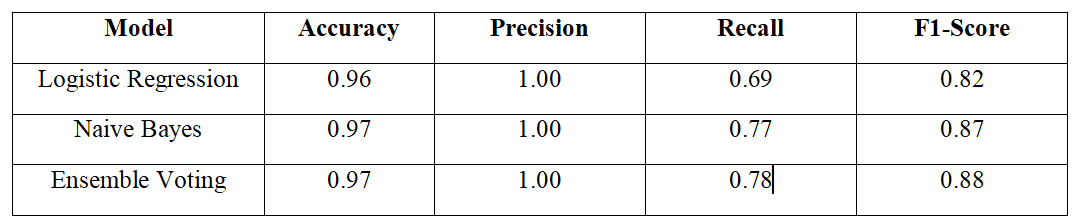

## Results and Anaysis (Visualization)

### Class Distribution Bar-chart

/tmp/ipykernel_2907/2809869795.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')


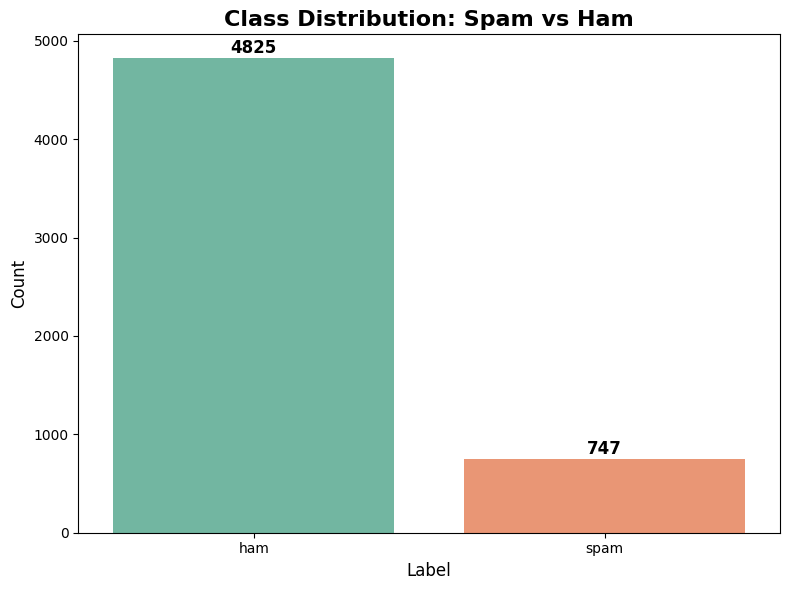

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df['label'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')
plt.title('Class Distribution: Spam vs Ham', fontsize=16, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()

### World Cloud

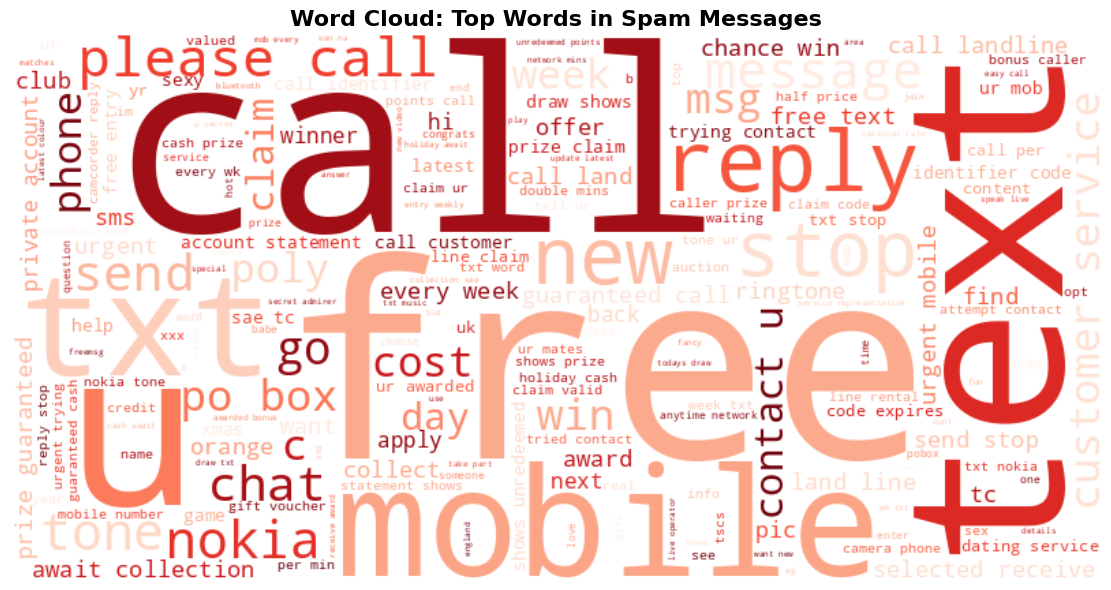

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


spam_df = df[df['label'] == 'spam']
spam_words = ' '.join(spam_df['clean_text'].astype(str).tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(spam_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Top Words in Spam Messages', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('spam_wordcloud.png', dpi=300)
plt.show()

### Comfusion Martix Heat Map

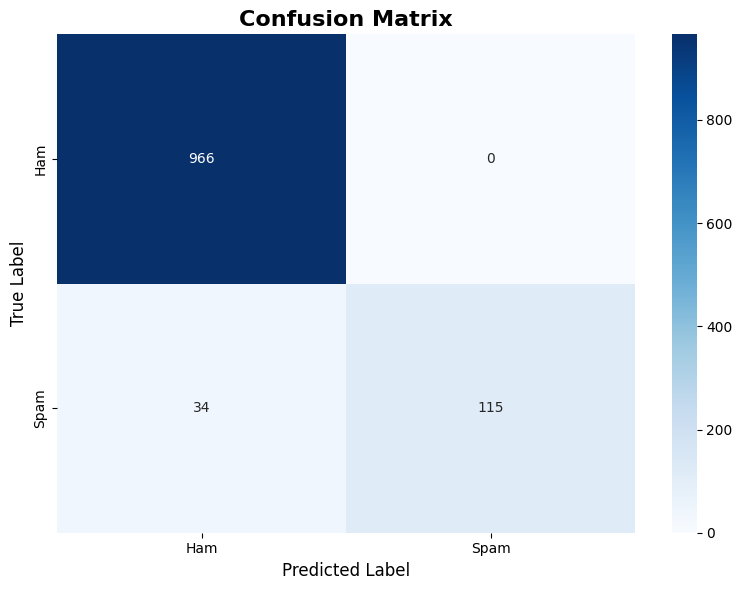

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

### Model Comparison For F1-Score

/tmp/ipykernel_2907/1755085582.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette='viridis')


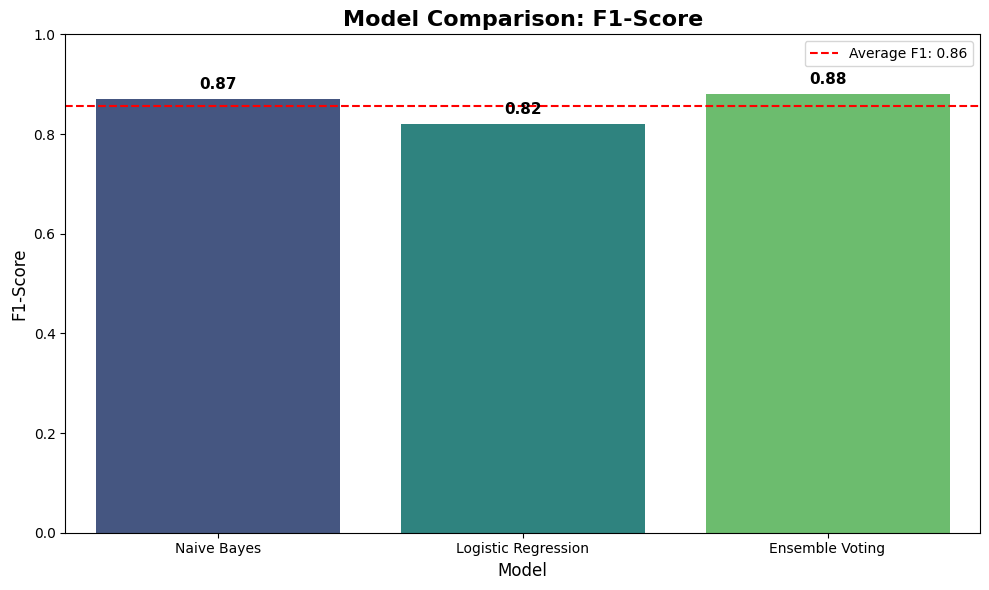

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Naive Bayes': {
        'accuracy': 0.96,
        'precision': 1.00,
        'recall': 0.77,
        'f1_score': 0.8712
    },
    'Logistic Regression': {
        'accuracy': 0.95,
        'precision': 1.00,
        'recall': 0.69,
        'f1_score': 0.82
    },
    'Ensemble Voting': {
        'accuracy': 0.97,
        'precision': 1.00,
        'recall': 0.78,
        'f1_score': 0.8797
    }
}

model_names = list(models.keys())
f1_scores = [models[m]['f1_score'] for m in models]
accuracy_scores = [models[m]['accuracy'] for m in models]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f1_scores, palette='viridis')
plt.axhline(y=sum(f1_scores)/len(f1_scores), color='red', linestyle='--',
            label=f'Average F1: {sum(f1_scores)/len(f1_scores):.2f}')
plt.title('Model Comparison: F1-Score', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=300)
plt.show()

## Cross Validation Score For Naive Bayes and Ensamble

In [ ]:
from sklearn.model_selection import cross_val_score

nb_cv = cross_val_score(MultinomialNB(), X, y, cv=5)
ensemble_cv = cross_val_score(ensemble, X, y, cv=5)

print(f"Naive Bayes CV Accuracy: {nb_cv.mean():.4f} (+/- {nb_cv.std()*2:.4f})")
print(f"Ensemble CV Accuracy: {ensemble_cv.mean():.4f} (+/- {ensemble_cv.std()*2:.4f})")

Naive Bayes CV Accuracy: 0.9709 (+/- 0.0055)
Ensemble CV Accuracy: 0.9715 (+/- 0.0061)
